# Intervalos de confianza con fórmula

## ¿Qué es un intervalo de confianza?
Es un rango de valores dentro del cual esperamos que esté el parámetro real de la población.

## Interpretación práctica
Un intervalo del 95% indica que, si repitiéramos el procedimiento muchas veces, una gran proporción de esos intervalos contendría el verdadero valor poblacional.

## Factores que afectan el intervalo
- Más confianza -> intervalo más ancho
- Más datos -> intervalo más estrecho
- Más variabilidad -> intervalo más ancho

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from scipy.stats import norm

In [3]:
penguins = sns.load_dataset("penguins").dropna()
muestra = penguins.sample(n=80, random_state=42)

In [4]:
media = muestra["body_mass_g"].mean()
s = muestra["body_mass_g"].std()
n = len(muestra)

In [5]:
z = norm.ppf(0.975)  # 95%
margen = z * (s / np.sqrt(n))

In [6]:
li = media - margen
ls = media + margen

In [7]:
print("Media muestral:", round(media, 2))
print("IC 95%:", (round(li, 2), round(ls, 2)))

Media muestral: 4212.19
IC 95%: (np.float64(4039.55), np.float64(4384.82))


In [8]:
media_poblacion = penguins["body_mass_g"].mean()
print("Media poblacional real:", round(media_poblacion, 2))

Media poblacional real: 4207.06


# Intervalos de confianza con bootstrap

## ¿Por qué usar bootstrap?
Porque no siempre queremos depender de supuestos fuertes sobre la distribución.

## Procedimiento
1. Tomamos muchas muestras bootstrap
2. Calculamos el estadístico en cada una
3. Ordenamos los resultados
4. Tomamos percentiles para formar el intervalo

## Ventaja
Es una estrategia muy útil en ciencia de datos para estimar incertidumbre de manera práctica.

In [9]:
penguins = sns.load_dataset("penguins").dropna()
muestra = penguins.sample(n=80, random_state=42)

In [10]:
bootstrap_means = []

for _ in range(3000):
    bs = muestra.sample(n=len(muestra), replace=True)
    bootstrap_means.append(bs["body_mass_g"].mean())

bootstrap_means = pd.Series(bootstrap_means)

In [11]:
li = bootstrap_means.quantile(0.025)
ls = bootstrap_means.quantile(0.975)

In [12]:
print("Media muestral:", round(muestra['body_mass_g'].mean(), 2))
print("IC bootstrap 95%:", (round(li, 2), round(ls, 2)))

Media muestral: 4212.19
IC bootstrap 95%: (np.float64(4049.34), np.float64(4383.44))


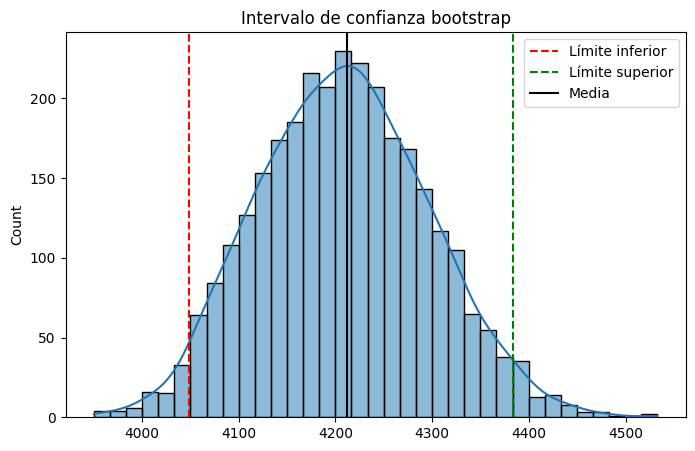

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(bootstrap_means, kde=True)
plt.axvline(li, color="red", linestyle="--", label="Límite inferior")
plt.axvline(ls, color="green", linestyle="--", label="Límite superior")
plt.axvline(muestra["body_mass_g"].mean(), color="black", label="Media")
plt.title("Intervalo de confianza bootstrap")
plt.legend()
plt.show()